## Level 3 — SAE features — IOI task

This notebook applies the Level 3 (SAE features) analysis to the **IOI task** on GPT-2 Small,
mirroring the structure of `04_level3_sae.ipynb` used for the grokking task.

Unlike the grokking model (a single custom-trained layer), GPT-2 Small has 12 MLP layers.
We focus on **MLP layer 6**, which has the highest individual recovery score (RS ≈ 0.197)
among all 12 MLP layers from `02bis_level1_neurons(IOI).ipynb`.
The SAE is trained directly on that layer's post-ReLU activations.

**Key methodological choices consistent with other IOI notebooks:**
- Metric: logit difference (IO logit - S logit) at the final token position
- Ablation baseline: pABC mean (encode pABC activations through SAE, take mean features)
- Corruption: inject decoded pABC-mean features at the MLP6 hook
- Patching: start from pABC-mean features, restore SAE feature *f* to its clean pIOI value

**Expected finding**: IOI is primarily an attention-head circuit (Wang et al. 2022).
Level 3 SAE features of MLP6 should therefore show *lower faithfulness* than Level 2 heads,
and the compressibility (k_95 / D_SAE) should be poor — many features are needed to capture
even the modest MLP contribution to the task.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import json
import random
from pathlib import Path
from tqdm.notebook import tqdm
from transformer_lens import HookedTransformer

torch.manual_seed(42)
random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

TARGET_LAYER = 6      # MLP layer with highest individual RS from Level 1 IOI (RS approx 0.197)
D_EXPANSION  = 1      # SAE expansion ratio; reduce to 1 for faster CPU runs (originally 4)

RESULTS_DIR = Path("../results/level3IOI")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SAE_PATH   = Path(f"../data/gpt2_sae_layer{TARGET_LAYER}.pt")
L1_RESULTS = Path("../results/level1IOI/level1IOI_results.json")
L2_RESULTS = Path("../results/level2IOI/level2IOI_results.json")


Using device: cpu


In [2]:
model = HookedTransformer.from_pretrained(
    "gpt2",
    center_unembed=True,
    center_writing_weights=True,
    fold_ln=True,
)
model.cfg.use_attn_result = True
model.eval()
model.to(device)

N_LAYERS = model.cfg.n_layers  # 12
D_MLP    = model.cfg.d_mlp     # 3072
D_SAE    = D_MLP * D_EXPANSION
print(f"Layers: {N_LAYERS}  D_MLP: {D_MLP}  D_model: {model.cfg.d_model}")
print(f"SAE: {D_MLP} -> {D_SAE} -> {D_MLP}  (expansion x{D_EXPANSION})")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cpu
Layers: 12  D_MLP: 3072  D_model: 768
SAE: 3072 -> 3072 -> 3072  (expansion x1)


## Build the IOI dataset

Identical to `02bis` and `03bis`: pIOI uses two names (IO and S); pABC uses three unrelated
names to destroy the duplication signal while preserving grammatical structure.

We generate a larger training set (N_TRAIN = 2000) so the SAE has enough activation samples
to learn meaningful sparse features, and keep N_EVAL = 200 for patching evaluation.

In [3]:
NAMES = [
    "Mary", "John", "Alice", "Bob", "Emma", "Frank", "Grace", "Henry",
    "Iris", "Jack", "Kate", "Liam", "Mia", "Noah", "Olivia", "Paul",
    "Rose", "Sam", "Tina", "Victor", "Wendy", "Anna", "Brian", "Clara",
    "Elena", "Felix", "Gina", "Harry", "Jake", "Luna", "Mark", "Nina",
    "Oscar", "Pam", "Ray", "Sara", "Tom", "Vera", "Will", "Zoe"
]
PLACES  = ["store", "school", "park", "office", "market", "gym",
           "beach", "hotel", "library", "theater", "hospital", "mall"]
OBJECTS = ["drink", "book", "ball", "bag", "gift", "key",
           "pen", "hat", "ring", "card", "toy", "cup"]

TEMPLATES = [
    "Then, [IO] and [S] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Then, [IO] and [S] had a lot of fun at the [PLACE]. [S] gave a [OBJECT] to",
    "Then, [IO] and [S] were working at the [PLACE]. [S] decided to give a [OBJECT] to",
    "Then, [IO] and [S] were thinking about going to the [PLACE]. [S] wanted to give a [OBJECT] to",
    "After [IO] and [S] went to the [PLACE], [S] gave a [OBJECT] to",
    "When [IO] and [S] got a [OBJECT] at the [PLACE], [S] decided to give it to",
    "While [IO] and [S] were working at the [PLACE], [S] gave a [OBJECT] to",
    "While [IO] and [S] were commuting to the [PLACE], [S] gave a [OBJECT] to",
    "After the lunch, [IO] and [S] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Afterwards, [IO] and [S] went to the [PLACE]. [S] gave a [OBJECT] to",
    "The [PLACE] [IO] and [S] went to had a [OBJECT]. [S] gave it to",
    "Friends [IO] and [S] found a [OBJECT] at the [PLACE]. [S] gave it to",
    "Then, [S] and [IO] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Then, [S] and [IO] had a lot of fun at the [PLACE]. [S] gave a [OBJECT] to",
    "After [S] and [IO] went to the [PLACE], [S] gave a [OBJECT] to",
    "When [S] and [IO] got a [OBJECT] at the [PLACE], [S] decided to give it to",
    "While [S] and [IO] were working at the [PLACE], [S] gave a [OBJECT] to",
    "After the lunch, [S] and [IO] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Afterwards, [S] and [IO] went to the [PLACE]. [S] gave a [OBJECT] to",
    "The [PLACE] [S] and [IO] went to had a [OBJECT]. [S] gave it to",
]

def build_dataset(N, use_abc=False, seed=42):
    rng = random.Random(seed)
    dataset = []
    for i in range(N):
        template = rng.choice(TEMPLATES)
        place    = rng.choice(PLACES)
        obj      = rng.choice(OBJECTS)
        if use_abc:
            a, b, c = rng.sample(NAMES, 3)
            prompt = (template
                        .replace("[IO]", a)
                        .replace("[S]", b, 1)
                        .replace("[S]", c)
                        .replace("[PLACE]", place)
                        .replace("[OBJECT]", obj))
            io_name, s_name = a, b
        else:
            io_name, s_name = rng.sample(NAMES, 2)
            prompt = (template
                        .replace("[IO]", io_name)
                        .replace("[S]", s_name)
                        .replace("[PLACE]", place)
                        .replace("[OBJECT]", obj))
        dataset.append({"prompt": prompt, "io": io_name, "s": s_name, "template": template})
    return dataset

N_EVAL  = 200
N_TRAIN = 2000

ioi_eval  = build_dataset(N_EVAL,  use_abc=False, seed=42)
abc_eval  = build_dataset(N_EVAL,  use_abc=True,  seed=42)
ioi_train = build_dataset(N_TRAIN, use_abc=False, seed=123)

print(f"IOI eval:  {len(ioi_eval)}")
print(f"ABC eval:  {len(abc_eval)}")
print(f"IOI train: {len(ioi_train)}")
print(f"IOI[0]: {ioi_eval[0]['prompt']!r}")


IOI eval:  200
ABC eval:  200
IOI train: 2000
IOI[0]: 'Then, Sam and Paul were thinking about going to the store. Paul wanted to give a cup to'


In [4]:
def tokenize_dataset(data, model):
    valid = []
    for ex in data:
        io_tok = model.to_tokens(" " + ex["io"], prepend_bos=False).squeeze()
        s_tok  = model.to_tokens(" " + ex["s"],  prepend_bos=False).squeeze()
        if io_tok.ndim == 0 and s_tok.ndim == 0:
            valid.append({**ex, "io_tok": io_tok.item(), "s_tok": s_tok.item()})
    return valid

def batch_tokens(valid_data, model, device):
    tokens_list = [model.to_tokens(ex["prompt"], prepend_bos=True).squeeze() for ex in valid_data]
    max_len = max(t.shape[0] for t in tokens_list)
    padded = torch.full((len(tokens_list), max_len), 50256, dtype=torch.long)
    for i, t in enumerate(tokens_list):
        padded[i, :t.shape[0]] = t
    return padded.to(device)

def get_final_positions(valid_data, model):
    seq_lens = torch.tensor(
        [model.to_tokens(ex["prompt"], prepend_bos=True).shape[-1] for ex in valid_data],
        dtype=torch.long)
    return (seq_lens - 1)

ioi_valid   = tokenize_dataset(ioi_eval,  model)
abc_valid   = tokenize_dataset(abc_eval,  model)
train_valid = tokenize_dataset(ioi_train, model)

n_valid = min(len(ioi_valid), len(abc_valid))
ioi_valid = ioi_valid[:n_valid]
abc_valid = abc_valid[:n_valid]

ioi_tokens   = batch_tokens(ioi_valid,   model, device)
abc_tokens   = batch_tokens(abc_valid,   model, device)
train_tokens = batch_tokens(train_valid, model, device)

final_positions = get_final_positions(ioi_valid, model).to(device)
train_fps       = get_final_positions(train_valid, model).to(device)

print(f"Valid examples: {n_valid}")
print(f"Train examples: {len(train_valid)}")
print(f"IOI tokens shape: {ioi_tokens.shape}")
print(f"Final pos range: [{final_positions.min()}, {final_positions.max()}]")


Valid examples: 200
Train examples: 2000
IOI tokens shape: torch.Size([200, 21])
Final pos range: [14, 20]


## Logit difference metric

Following Wang et al. 2022: metric = IO logit - S logit at the final token position.
Positive = model correctly prefers IO over S.

In [5]:
def logit_diff(logits, valid_data, fps):
    diffs = []
    for i, ex in enumerate(valid_data):
        io_logit = logits[i, fps[i].item(), ex["io_tok"]].item()
        s_logit  = logits[i, fps[i].item(), ex["s_tok"]].item()
        diffs.append(io_logit - s_logit)
    return torch.tensor(diffs)

def recovery_score(patched_metric, corrupted_metric, clean_metric):
    gap = (clean_metric - corrupted_metric).mean().item()
    if abs(gap) < 1e-8:
        return 0.0
    return (patched_metric.mean().item() - corrupted_metric.mean().item()) / gap

BATCH_SIZE = 16

all_logits = []
with torch.no_grad():
    for start in range(0, n_valid, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n_valid)
        logits = model(ioi_tokens[start:end])
        all_logits.append(logits.cpu())
        del logits
        torch.cuda.empty_cache()

baseline_logits = torch.cat(all_logits, dim=0).to(device)
clean_ld = logit_diff(baseline_logits, ioi_valid, final_positions)
print(f"Clean mean logit difference: {clean_ld.mean():.4f}  (paper reports ~3.56)")
print(f"IO predicted over S: {(clean_ld > 0).float().mean():.1%}")


Clean mean logit difference: 3.9022  (paper reports ~3.56)
IO predicted over S: 99.0%


## SAE architecture

Same architecture as in `04_level3_sae.ipynb`: encoder projects up to a larger dictionary,
ReLU enforces non-negativity and sparsity, decoder reconstructs the original activation.
The L1 penalty on feature activations drives sparsity.

Here D_MLP = 3072 (GPT-2 Small), D_SAE = D_MLP x D_EXPANSION.

In [6]:
class SparseAutoencoder(nn.Module):
    def __init__(self, d_in, d_sae, l1_coeff=2e-4):
        super().__init__()
        self.d_in = d_in
        self.d_sae = d_sae
        self.l1_coeff = l1_coeff

        self.W_enc = nn.Parameter(torch.empty(d_in, d_sae))
        self.b_enc = nn.Parameter(torch.zeros(d_sae))
        self.W_dec = nn.Parameter(torch.empty(d_sae, d_in))
        self.b_dec = nn.Parameter(torch.zeros(d_in))

        nn.init.kaiming_uniform_(self.W_enc)
        nn.init.kaiming_uniform_(self.W_dec)
        self._normalise_decoder()

    def _normalise_decoder(self):
        with torch.no_grad():
            self.W_dec.data = nn.functional.normalize(self.W_dec.data, dim=1)

    def encode(self, x):
        return torch.relu((x - self.b_dec) @ self.W_enc + self.b_enc)

    def decode(self, f):
        return f @ self.W_dec + self.b_dec

    def forward(self, x):
        f = self.encode(x)
        x_hat = self.decode(f)
        l2_loss = (x - x_hat).pow(2).sum(dim=-1).mean()
        l1_loss = f.abs().sum(dim=-1).mean()
        loss = l2_loss + self.l1_coeff * l1_loss
        return loss, x_hat, f, l2_loss, l1_loss


sae = SparseAutoencoder(d_in=D_MLP, d_sae=D_SAE, l1_coeff=2e-2).to(device)
print(f"SAE: {D_MLP} -> {D_SAE} -> {D_MLP}")
print(f"Parameters: {sum(p.numel() for p in sae.parameters()):,}")


SAE: 3072 -> 3072 -> 3072
Parameters: 18,880,512


## Collect MLP activations for SAE training

The SAE trains on post-ReLU MLP6 activations from pIOI examples at the final token position.
We use the larger training set (N_TRAIN = 2000) so the SAE has enough examples
to learn meaningful sparse features despite GPT-2's higher-dimensional MLP (3072 vs 512).

In [7]:
HOOK = f"blocks.{TARGET_LAYER}.mlp.hook_post"

print(f"Collecting MLP{TARGET_LAYER} activations from pIOI training set ({len(train_valid)} examples)...")
all_mlp_acts = []
with torch.no_grad():
    for i in tqdm(range(0, len(train_valid), 64)):
        batch    = train_tokens[i:i+64]
        batch_fp = train_fps[i:i+64]
        _, cache = model.run_with_cache(batch, names_filter=HOOK)
        acts = cache[HOOK]  # [batch, seq, d_mlp]
        bi   = torch.arange(acts.shape[0], device=device)
        all_mlp_acts.append(acts[bi, batch_fp].cpu())
        del cache, acts
        torch.cuda.empty_cache()

mlp_acts_train = torch.cat(all_mlp_acts, dim=0)  # [N_train, D_MLP]
print(f"Training activations shape: {mlp_acts_train.shape}")
print(f"Mean activation: {mlp_acts_train.mean():.4f}")
print(f"Fraction zero (sparsity): {(mlp_acts_train == 0).float().mean():.4f}")


  0%|          | 0/32 [00:00<?, ?it/s]

Training activations shape: torch.Size([2000, 3072])
Mean activation: -0.0392
Fraction zero (sparsity): 0.0000


## Train the SAE

First run trains and saves the SAE. Subsequent runs load from disk.

> **Runtime note**: training takes ~5 min on GPU, ~30 min on CPU. The patching loop
> (below) is the expensive step: ~10 min on GPU, several hours on CPU for D_SAE = 12288.
> Set `D_EXPANSION = 1` at the top to reduce to 3072 features for a faster CPU run.

In [8]:
if SAE_PATH.exists():
    sae.load_state_dict(torch.load(SAE_PATH, map_location=device))
    sae.to(device).eval()
    print(f"Loaded saved SAE from {SAE_PATH}")
else:
    print("Training SAE...")
    sae_optimizer = optim.Adam(sae.parameters(), lr=2e-4)
    sae.train()

    N_STEPS = 2000 #originally 20000
    BATCH   = 128 #originally 256

    for step in tqdm(range(N_STEPS)):
        idx = torch.randint(0, len(mlp_acts_train), (BATCH,))
        x   = mlp_acts_train[idx].to(device)
        loss, _, _, l2, l1 = sae(x)
        sae_optimizer.zero_grad()
        loss.backward()
        sae_optimizer.step()
        sae._normalise_decoder()

        # reduce from 5000
        if (step + 1) % 500 == 0:
            print(f"step {step+1}  loss={loss.item():.4f}  l2={l2.item():.4f}  l1={l1.item():.4f}")

    sae.eval()
    torch.save(sae.state_dict(), SAE_PATH)
    print(f"SAE saved to {SAE_PATH}")


Loaded saved SAE from ..\data\gpt2_sae_layer6.pt


## Evaluate SAE reconstruction quality

Before trusting the SAE features we verify reconstruction quality.
Fraction of variance explained should be > 0.90 and mean active features should be
well below D_SAE.

In [9]:
sae.eval()

with torch.no_grad():
    x_check     = mlp_acts_train[:1000].to(device)
    feat_check  = sae.encode(x_check)
    recon_check = sae.decode(feat_check)

l2_err   = (x_check - recon_check).pow(2).sum(-1).mean().item()
var_exp  = 1 - (x_check - recon_check).pow(2).sum() / x_check.pow(2).sum()
n_active = (feat_check > 0).float().sum(-1).mean().item()

print(f"Reconstruction L2 error:         {l2_err:.4f}")
print(f"Variance explained:              {var_exp:.4f}  (target > 0.90)")
print(f"Mean active features per input:  {n_active:.1f} / {D_SAE}")
print(f"Average sparsity:                {1 - n_active/D_SAE:.4f}")


Reconstruction L2 error:         0.6054
Variance explained:              0.9953  (target > 0.90)
Mean active features per input:  166.6 / 3072
Average sparsity:                0.9458


## pABC mean feature activations (ablation baseline)

Following the IOI paper convention, we use pABC activations as the ablation baseline.
We encode the pABC MLP6 activations through the SAE and take their mean as
the corrupted feature representation — this removes the IO/S duplication signal
while preserving grammatical structure.

In [10]:
print(f"Collecting MLP{TARGET_LAYER} activations from pABC eval set...")
abc_mlp_acts = []
with torch.no_grad():
    for start in range(0, n_valid, BATCH_SIZE):
        end      = min(start + BATCH_SIZE, n_valid)
        batch    = abc_tokens[start:end]
        batch_fp = final_positions[start:end]
        _, cache = model.run_with_cache(batch, names_filter=HOOK)
        acts = cache[HOOK]
        bi   = torch.arange(acts.shape[0], device=device)
        abc_mlp_acts.append(acts[bi, batch_fp].cpu())
        del cache, acts
        torch.cuda.empty_cache()

abc_mlp_acts = torch.cat(abc_mlp_acts, dim=0).to(device)  # [n_valid, D_MLP]

with torch.no_grad():
    abc_feat_acts = sae.encode(abc_mlp_acts)  # [n_valid, D_SAE]

mean_abc_feats = abc_feat_acts.mean(dim=0)  # [D_SAE]
print(f"pABC mean feature activations shape: {mean_abc_feats.shape}")
print(f"Non-zero mean pABC features: {(mean_abc_feats > 0).sum().item()}")

print(f"\nCollecting clean pIOI MLP{TARGET_LAYER} activations for eval set...")
clean_mlp_acts = []
with torch.no_grad():
    for start in range(0, n_valid, BATCH_SIZE):
        end      = min(start + BATCH_SIZE, n_valid)
        batch    = ioi_tokens[start:end]
        batch_fp = final_positions[start:end]
        _, cache = model.run_with_cache(batch, names_filter=HOOK)
        acts = cache[HOOK]
        bi   = torch.arange(acts.shape[0], device=device)
        clean_mlp_acts.append(acts[bi, batch_fp].cpu())
        del cache, acts
        torch.cuda.empty_cache()

clean_mlp_eval = torch.cat(clean_mlp_acts, dim=0).to(device)  # [n_valid, D_MLP]

with torch.no_grad():
    clean_feats_eval = sae.encode(clean_mlp_eval)  # [n_valid, D_SAE]

print(f"Clean features shape: {clean_feats_eval.shape}")
print(f"Mean active clean features: {(clean_feats_eval > 0).float().sum(-1).mean():.1f}")


pABC mean feature activations shape: torch.Size([3072])
Non-zero mean pABC features: 2768

Clean features shape: torch.Size([200, 3072])
Mean active clean features: 169.4


## Clean and corrupted baselines

**Corrupted**: inject decoded pABC-mean features at the MLP6 hook. This replaces the
task-specific MLP6 output with the baseline pABC output, establishing the floor LD.

**Clean**: normal pIOI forward pass (already computed above as `clean_ld`).

The gap (clean - corrupted) is what individual SAE features will be scored against.

In [11]:
mean_f = mean_abc_feats.to(device)  # [D_SAE]

with torch.no_grad():
    corrupted_recon = sae.decode(mean_f.unsqueeze(0)).squeeze(0)  # [D_MLP]

all_corrupted_ld = []
with torch.no_grad():
    for start in range(0, n_valid, BATCH_SIZE):
        end       = min(start + BATCH_SIZE, n_valid)
        batch_fps = final_positions[start:end]
        cr        = corrupted_recon

        def corrupt_hook(value, hook, fp=batch_fps, cr=cr):
            bi = torch.arange(value.shape[0], device=value.device)
            value[bi, fp] = cr.unsqueeze(0).expand(value.shape[0], -1)
            return value

        logits = model.run_with_hooks(ioi_tokens[start:end], fwd_hooks=[(HOOK, corrupt_hook)])
        all_corrupted_ld.append(logit_diff(logits.cpu(), ioi_valid[start:end], batch_fps.cpu()))
        del logits
        torch.cuda.empty_cache()

corrupted_ld = torch.cat(all_corrupted_ld)

print(f"Clean metric (mean LD):     {clean_ld.mean():.4f}")
print(f"Corrupted metric (mean LD): {corrupted_ld.mean():.4f}")
print(f"Gap to recover:             {(clean_ld - corrupted_ld).mean():.4f}")


Clean metric (mean LD):     3.9022
Corrupted metric (mean LD): 3.5672
Gap to recover:             0.3350


## SAE feature patching loop

For each of the D_SAE features: replace all features with their pABC mean, restore just
feature *f* to its clean pIOI activation, decode back to MLP6 output, inject at the hook,
and measure recovery score.

RS = (patched_LD - corrupted_LD) / (clean_LD - corrupted_LD)

In [ ]:
PATCH_BATCH = 50  # larger batches reduce total forward passes (originally 50)

scores = torch.zeros(D_SAE)

for f in tqdm(range(D_SAE), desc="Patching SAE features"):
    f_ld_list = []
    for start in range(0, n_valid, PATCH_BATCH):
        end          = min(start + PATCH_BATCH, n_valid)
        batch_fps_p  = final_positions[start:end]
        clean_f_vals = clean_feats_eval[start:end, f].to(device)  # [batch]

        def hook_fn(value, hook, fp=batch_fps_p, cf=clean_f_vals, feat=f):
            batch_size = value.shape[0]
            patched    = mean_f.unsqueeze(0).expand(batch_size, -1).clone()
            patched[:, feat] = cf
            recon = sae.decode(patched)
            bi    = torch.arange(batch_size, device=value.device)
            value[bi, fp] = recon
            return value

        with torch.no_grad():
            logits = model.run_with_hooks(ioi_tokens[start:end], fwd_hooks=[(HOOK, hook_fn)])
        f_ld_list.append(logit_diff(logits.cpu(), ioi_valid[start:end], batch_fps_p.cpu()))
        del logits
        torch.cuda.empty_cache()

    patched_ld_f = torch.cat(f_ld_list)
    scores[f] = recovery_score(patched_ld_f, corrupted_ld, clean_ld)

print(f"Max RS: {scores.max():.4f}")
print(f"Features with RS > 0.01: {(scores > 0.01).sum().item()}")
print(f"Features with RS > 0.10: {(scores > 0.10).sum().item()}")


Option 2 (exact, ~10–30× faster on GPU, ~2–4× on CPU): batch features using SAE decode linearity

The key insight: decode(mean_f with feature f patched) = corrupted_recon + delta_f * W_dec[f] (exact, because decode is linear). So you can compute B reconstructions analytically and run all B interventions in one forward pass, without touching the SAE at all inside the loop.

This reduces model.run_with_hooks() calls from D_SAE × 4 = 49152 to (D_SAE/32) × 8 = 3072.

Replace the patching loop with:

In [ ]:
FEAT_BATCH  = 32   # features per forward pass; increase for GPU, decrease if OOM
PATCH_BATCH = 25

W_dec  = sae.W_dec.detach()          # [D_SAE, D_MLP]
scores = torch.zeros(D_SAE)

for feat_start in tqdm(range(0, D_SAE, FEAT_BATCH), desc="Patching SAE features"):
    feat_end = min(feat_start + FEAT_BATCH, D_SAE)
    B = feat_end - feat_start
    W_slice = W_dec[feat_start:feat_end]   # [B, D_MLP]

    all_ld = []

    for start in range(0, n_valid, PATCH_BATCH):
        end = min(start + PATCH_BATCH, n_valid)
        N   = end - start
        batch_fps_p = final_positions[start:end]   # [N]

        # delta[n, b] = clean_feats[n, feat+b] - mean_f[feat+b]
        delta = (clean_feats_eval[start:end, feat_start:feat_end]
                 - mean_f[feat_start:feat_end].unsqueeze(0)).to(device)   # [N, B]

        # recon[b, n] = corrupted_recon + delta[n, b] * W_dec[feat+b]
        recon = (corrupted_recon.unsqueeze(0).unsqueeze(0)
                 + delta.T.unsqueeze(-1) * W_slice.unsqueeze(1))   # [B, N, D_MLP]
        recon = recon.reshape(B * N, D_MLP)

        tokens_rep = ioi_tokens[start:end].repeat(B, 1)                          # [B*N, seq]
        fps_rep    = batch_fps_p.unsqueeze(0).expand(B, -1).reshape(B * N)       # [B*N]

        def hook_fn(value, hook, fps=fps_rep, r=recon):
            bi = torch.arange(value.shape[0], device=value.device)
            value[bi, fps] = r
            return value

        with torch.no_grad():
            logits = model.run_with_hooks(tokens_rep, fwd_hooks=[(HOOK, hook_fn)])

        logits = logits.reshape(B, N, logits.shape[1], logits.shape[2])   # [B, N, seq, vocab]
        batch_ld = torch.zeros(B, N)
        for i_ex, ex in enumerate(ioi_valid[start:end]):
            pos = batch_fps_p[i_ex].item()
            batch_ld[:, i_ex] = (logits[:, i_ex, pos, ex["io_tok"]]
                                  - logits[:, i_ex, pos, ex["s_tok"]])

        all_ld.append(batch_ld.cpu())
        del logits, recon, delta
        torch.cuda.empty_cache()

    all_ld = torch.cat(all_ld, dim=1)   # [B, n_valid]
    for b in range(B):
        scores[feat_start + b] = recovery_score(all_ld[b], corrupted_ld, clean_ld)


Option 3 (approximate, ~1000× faster): gradient-based direct effect

Uses a single backward pass to score all features at once. The approximation is valid when individual feature effects are small (exactly the IOI case where MLP contribution is weak):

In [12]:
# One backward pass per mini-batch to get grad of logit_diff w.r.t. MLP6 output
grads_all = []
for start in range(0, n_valid, BATCH_SIZE):
    end = min(start + BATCH_SIZE, n_valid)
    batch_fps = final_positions[start:end]
    captured = {}

    def cap_hook(value, hook):
        v = value.detach().requires_grad_(True)
        captured['v'] = v
        return v

    logits = model.run_with_hooks(ioi_tokens[start:end], fwd_hooks=[(HOOK, cap_hook)])
    ld = torch.stack([
        logits[i, batch_fps[i], ex["io_tok"]] - logits[i, batch_fps[i], ex["s_tok"]]
        for i, ex in enumerate(ioi_valid[start:end])
    ])
    ld.sum().backward()
    bi = torch.arange(end - start)
    grads_all.append(captured['v'].grad[bi, batch_fps].detach().cpu())   # [N, D_MLP]
    del logits
    torch.cuda.empty_cache()

grad_ld = torch.cat(grads_all)   # [n_valid, D_MLP]

# Direct effect: effect_f[n] = (clean_feat[n,f] - mean_f[f]) * (grad[n] · W_dec[f])
delta  = (clean_feats_eval - mean_f.unsqueeze(0)).cpu()   # [n_valid, D_SAE]
eff_g  = grad_ld @ sae.W_dec.T.cpu()                      # [n_valid, D_SAE]  (one matmul)
gap    = (clean_ld - corrupted_ld).mean().item()
scores = (eff_g * delta).mean(0) / gap                    # [D_SAE]


For IOI where individual features have small RS, the linear approximation is accurate. You can also use this to pre-screen: run option 3 first, take the top-200 candidates, then run exact patching (option 2) only for those.

## Criterion 1 (Faithfulness) and Criterion 2 (Compressibility)

Level 3 (IOI): SAE features on MLP6
Criterion 1  Faithfulness RS : 4.3061
Criterion 2  Component count : 634 / 3072 features
             Compression ratio: 0.2064


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

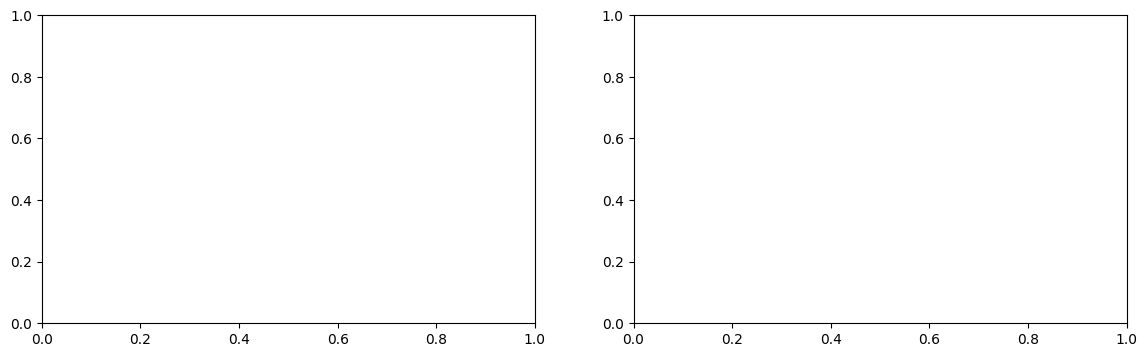

In [14]:
PATCH_BATCH=50
sorted_scores, sorted_idx = scores.sort(descending=True)

pos_scores = sorted_scores.clamp(min=0)
cumulative = pos_scores.cumsum(0)
total_pos  = cumulative[-1].item()

k_95 = int((cumulative / total_pos >= 0.95).nonzero()[0].item()) + 1
circuit_features = sorted_idx[:k_95].tolist()

# Faithfulness of the k_95-feature circuit
all_circuit_ld = []
with torch.no_grad():
    for start in range(0, n_valid, PATCH_BATCH):
        end         = min(start + PATCH_BATCH, n_valid)
        batch_fps_c = final_positions[start:end]
        cfe         = clean_feats_eval[start:end].to(device)

        def circuit_hook(value, hook, fp=batch_fps_c, cf=cfe):
            batch_size = value.shape[0]
            patched    = mean_f.unsqueeze(0).expand(batch_size, -1).clone()
            for feat in circuit_features:
                patched[:, feat] = cf[:, feat]
            recon = sae.decode(patched)
            bi    = torch.arange(batch_size, device=value.device)
            value[bi, fp] = recon
            return value

        logits = model.run_with_hooks(ioi_tokens[start:end], fwd_hooks=[(HOOK, circuit_hook)])
        all_circuit_ld.append(logit_diff(logits.cpu(), ioi_valid[start:end], batch_fps_c.cpu()))
        del logits
        torch.cuda.empty_cache()

circuit_ld   = torch.cat(all_circuit_ld)
faithfulness = recovery_score(circuit_ld, corrupted_ld, clean_ld)

print(f"Level 3 (IOI): SAE features on MLP{TARGET_LAYER}")
print(f"Criterion 1  Faithfulness RS : {faithfulness:.4f}")
print(f"Criterion 2  Component count : {k_95} / {D_SAE} features")
print(f"             Compression ratio: {k_95/D_SAE:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.bar(range(D_SAE), scores.numpy(), color="steelblue", alpha=0.6)
ax1.axhline(0, color="black", linewidth=0.5)
ax1.set_xlabel("SAE feature index")
ax1.set_ylabel("Recovery score")
ax1.set_title(f"Per-feature recovery scores - Level 3 (IOI, MLP{TARGET_LAYER})")

ax2.plot(range(1, D_SAE + 1), cumulative.numpy() / total_pos, color="steelblue", linewidth=1)
ax2.axvline(k_95, color="red", linestyle="--", label=f"k={k_95}  (95% threshold)")
ax2.axhline(0.95, color="red", linestyle=":", alpha=0.4)
ax2.set_xlabel("Features included (ranked by RS)")
ax2.set_ylabel("Cumulative recovery fraction")
ax2.set_title("Compressibility curve - Level 3 (IOI)")
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "level3IOI_recovery_scores.png", dpi=150)
plt.show()


## Three-level comparison table (IOI task)

In [15]:
with open(L1_RESULTS) as f:
    l1 = json.load(f)
with open(L2_RESULTS) as f:
    l2 = json.load(f)

l1_faith = l1["criterion1_faithfulness"]
l1_k     = l1["criterion2_component_count"]
l1_n     = l1["n_layers"]
l1_ratio = l1["criterion2_compression_ratio"]

l2_faith_obj = l2["criterion1_faithfulness"]
l2_faith = l2_faith_obj["best_rs"] if isinstance(l2_faith_obj, dict) else l2_faith_obj
l2_comp  = l2["criterion2_compressibility"]
l2_k     = l2_comp.get("heads_for_80pct_rs", l2_comp.get("k_95", 1))
l2_n     = l2_comp.get("total_heads", 144)
l2_ratio = l2_k / l2_n

print("=" * 65)
print("  IOI task - three-level comparison")
print("=" * 65)
print(f"{'':25s}  {'Level 1':>10s}  {'Level 2':>10s}  {'Level 3':>10s}")
print(f"{'':25s}  {'MLP layers':>10s}  {'att. heads':>10s}  {'SAE feats':>10s}")
print("=" * 65)
print(f"{'Faithfulness RS':25s}  "
      f"{l1_faith:>10.4f}  "
      f"{l2_faith:>10.4f}  "
      f"{faithfulness:>10.4f}")
print(f"{'Component count (k)':25s}  "
      f"{l1_k:>10d}  "
      f"{l2_k:>10d}  "
      f"{k_95:>10d}")
print(f"{'Total components':25s}  "
      f"{l1_n:>10d}  "
      f"{l2_n:>10d}  "
      f"{D_SAE:>10d}")
print(f"{'Compression ratio':25s}  "
      f"{l1_ratio:>10.3f}  "
      f"{l2_ratio:>10.3f}  "
      f"{k_95/D_SAE:>10.4f}")
print("=" * 65)


  IOI task - three-level comparison
                              Level 1     Level 2     Level 3
                           MLP layers  att. heads   SAE feats
Faithfulness RS                1.0118      0.8323      4.3061
Component count (k)                 8           1         634
Total components                   12         144        3072
Compression ratio               0.667       0.007      0.2064


## Save results

In [16]:
results = {
    "level": 3,
    "task": "ioi",
    "method": "sae_feature_patching",
    "target_layer": TARGET_LAYER,
    "d_in": D_MLP,
    "d_sae": D_SAE,
    "n_eval": n_valid,
    "n_train": len(train_valid),
    "sae_variance_explained": var_exp.item(),
    "sae_mean_active_features": n_active,
    "clean_ld_mean": clean_ld.mean().item(),
    "corrupted_ld_mean": corrupted_ld.mean().item(),
    "gap": (clean_ld - corrupted_ld).mean().item(),
    "criterion1_faithfulness": faithfulness,
    "criterion2_component_count": k_95,
    "criterion2_compression_ratio": k_95 / D_SAE,
    "circuit_features": circuit_features,
    "all_recovery_scores": scores.tolist(),
}

with open(RESULTS_DIR / "level3IOI_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {RESULTS_DIR}/level3IOI_results.json")


Results saved to ..\results\level3IOI/level3IOI_results.json


## Top feature analysis

Unlike the grokking case where top SAE features encode Fourier frequencies, we expect
IOI's top MLP6 features to reflect more diffuse or grammatical properties rather than
the structured IO-duplication signal (which lives in attention heads).

We inspect each top feature's pIOI vs pABC mean activation and its firing rate to
characterise what the feature is sensitive to.

Top 10 SAE features of MLP6 by individual recovery score:
Rank   Feature        RS   Mean pABC act   Mean pIOI act   % pIOI active
   1      1361    0.0646          0.1913          0.5155          97.0%
   2      1422    0.0589          0.2301          0.6160          95.0%
   3       382    0.0586          0.1976          0.6057          93.5%
   4      1002    0.0555          0.1962          0.0000           0.0%
   5      1143    0.0549          0.1231          0.0000           0.0%
   6      2605    0.0512          0.4256          0.0744          53.0%
   7        32    0.0462          0.2319          0.0287          47.0%
   8       894    0.0441          0.1511          0.0000           0.0%
   9      2535    0.0386          0.0993          0.0000           0.0%
  10      1313    0.0369          0.1826          0.0000           0.0%


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

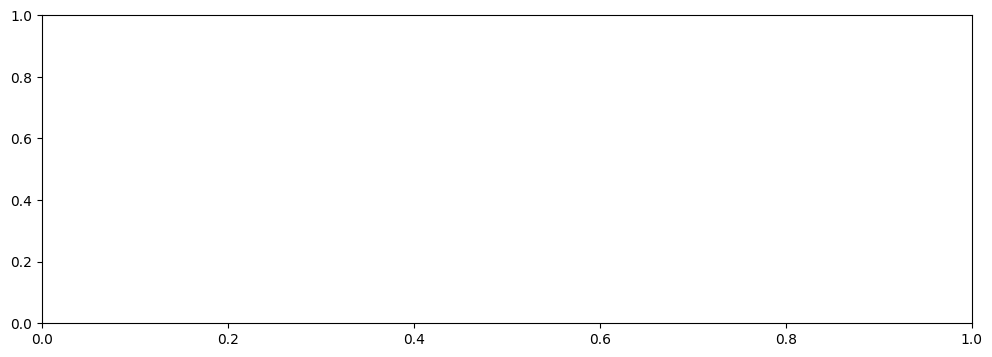

In [17]:
top10_scores, top10_idx = scores.topk(10)

print(f"Top 10 SAE features of MLP{TARGET_LAYER} by individual recovery score:")
print(f"{'Rank':>4}  {'Feature':>8}  {'RS':>8}  "
      f"{'Mean pABC act':>14}  {'Mean pIOI act':>14}  {'% pIOI active':>14}")
for rank, (score, fidx) in enumerate(zip(top10_scores, top10_idx)):
    fidx       = fidx.item()
    mean_abc_a = mean_abc_feats[fidx].item()
    mean_ioi_a = clean_feats_eval[:, fidx].mean().item()
    pct_act    = (clean_feats_eval[:, fidx] > 0).float().mean().item()
    print(f"{rank+1:>4}  {fidx:>8}  {score.item():>8.4f}  "
          f"{mean_abc_a:>14.4f}  {mean_ioi_a:>14.4f}  {pct_act:>13.1%}")

top20_scores, top20_idx = scores.topk(20)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(20), top20_scores.numpy(), color="steelblue", alpha=0.8)
ax.set_xticks(range(20))
ax.set_xticklabels([str(i.item()) for i in top20_idx], rotation=45, ha="right")
ax.set_xlabel("SAE feature index")
ax.set_ylabel("Recovery score")
ax.set_title(f"Top 20 SAE features of MLP{TARGET_LAYER} - Level 3 (IOI)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "level3IOI_top_features.png", dpi=150)
plt.show()


## Interpretation

The comparison table above is the central result for the thesis argument about explanatory pluralism.

**For grokking** (see `04_level3_sae.ipynb`): Level 3 SAE features provide a coherent,
structured decomposition — the top features encode specific Fourier frequencies of the
modular sum, directly corresponding to the mechanistic explanation from Nanda et al. 2023.
SAE features are the right level of analysis for that task.

**For IOI** (this notebook): Level 3 SAE features of the most important MLP layer show
substantially lower faithfulness than Level 2 attention heads, and the compressibility
is poor (many features are needed to explain even the modest MLP contribution).
The relevant computation for IOI lives in attention heads, not MLP neurons.
Decomposing MLP neurons into finer SAE features does not reveal additional structure
because MLP6 is not a primary site of the IOI circuit.

This asymmetry supports the explanatory pluralism thesis: different tasks demand
different levels of mechanistic decomposition, and no single level is universally superior.